# Лабораторная 8

Генерация изображений себя в разных окружениях с помощью предобученной модели `Stable Diffusion`.

Главное ограничение: итоговые изображения создаются только из текста. Для сохранения лица используется короткое DreamBooth LoRA-дообучение на личных фотографиях, но `image-to-image` и `negative_prompt` не используются.

## Импорты и конфигурация

In [2]:
from __future__ import annotations

import os
import random
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

os.environ.setdefault("MPLCONFIGDIR", str(Path(".mplconfig").resolve()))
os.environ.setdefault("HF_HOME", str(Path(".cache/huggingface").resolve()))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32
MIXED_PRECISION = "fp16" if DEVICE.type == "cuda" else "no"

PERSON_DIR = Path("data/person")
TRAIN_PERSON_DIR = Path("data/person_train_clean")
OUTPUT_DIR = Path("output")
MODEL_DIR = Path("models")
SCRIPT_DIR = Path("scripts")

for folder in [PERSON_DIR, TRAIN_PERSON_DIR, OUTPUT_DIR, MODEL_DIR, SCRIPT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

GENDER_WORD = "man"

INSTANCE_TOKEN = "gera"
INSTANCE_PROMPT = f"photo of {INSTANCE_TOKEN} {GENDER_WORD}"

BASE_MODEL = "runwayml/stable-diffusion-v1-5"
LORA_DIR = MODEL_DIR / f"stable_diffusion_lora_{INSTANCE_TOKEN}_fast"

print(f"Device: {DEVICE}; dtype: {DTYPE}; mixed_precision: {MIXED_PRECISION}")

Device: mps; dtype: torch.float32; mixed_precision: no


## Личные фотографии

6

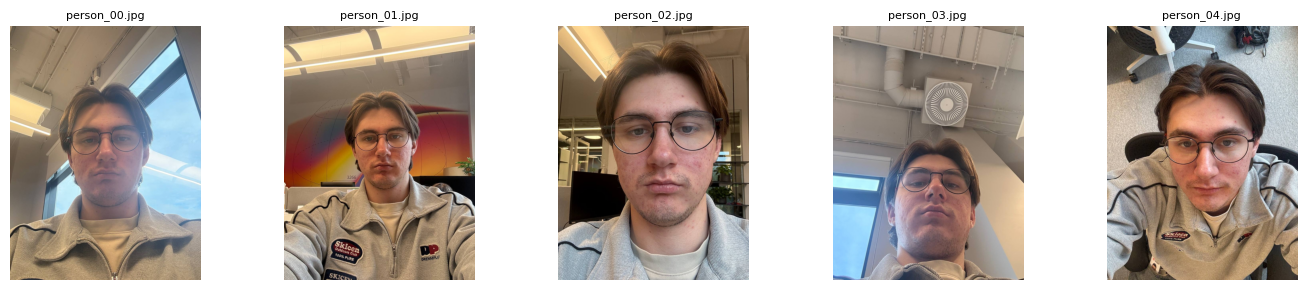

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}
person_images = sorted(p for p in PERSON_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS)

if len(person_images) < 5:
    raise FileNotFoundError(
        f"В {PERSON_DIR.resolve()} найдено {len(person_images)} изображений. "
        "Для нормального сохранения лица положите хотя бы 5 личных фотографий."
    )

shutil.rmtree(TRAIN_PERSON_DIR, ignore_errors=True)
TRAIN_PERSON_DIR.mkdir(parents=True, exist_ok=True)

valid_person_images = []
for index, source_path in enumerate(person_images):
    try:
        image = Image.open(source_path).convert("RGB")
        clean_path = TRAIN_PERSON_DIR / f"person_{index:02d}.jpg"
        image.save(clean_path, quality=95)
        valid_person_images.append(clean_path)
    except Exception as exc:
        print(f"Пропущен файл {source_path.name}: {exc}")

if len(valid_person_images) < 5:
    raise FileNotFoundError(
        f"После проверки осталось {len(valid_person_images)} валидных изображений. "
        "Проверьте, что в папке лежат обычные jpg/png/webp-фото."
    )

fig, axes = plt.subplots(1, min(5, len(valid_person_images)), figsize=(14, 3))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax, path in zip(axes, valid_person_images[:5]):
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
len(valid_person_images)

## DreamBooth LoRA

In [4]:
import diffusers

train_script = SCRIPT_DIR / "train_dreambooth_lora.py"
script_url = f"https://raw.githubusercontent.com/huggingface/diffusers/v{diffusers.__version__}/examples/dreambooth/train_dreambooth_lora.py"

if not train_script.exists():
    try:
        urllib.request.urlretrieve(script_url, train_script)
    except Exception:
        fallback_url = "https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py"
        urllib.request.urlretrieve(fallback_url, train_script)

train_script

PosixPath('scripts/train_dreambooth_lora.py')

In [ ]:
MAX_TRAIN_STEPS = 300
LEARNING_RATE = "1e-4"
RESOLUTION = 384
GRADIENT_ACCUMULATION_STEPS = 1
LORA_RANK = 16

cmd = [
    sys.executable,
    "-m",
    "accelerate.commands.launch",
    "--mixed_precision",
    MIXED_PRECISION,
    str(train_script),
    "--pretrained_model_name_or_path",
    BASE_MODEL,
    "--instance_data_dir",
    str(TRAIN_PERSON_DIR),
    "--output_dir",
    str(LORA_DIR),
    "--instance_prompt",
    INSTANCE_PROMPT,
    "--resolution",
    str(RESOLUTION),
    "--train_batch_size",
    "1",
    "--gradient_accumulation_steps",
    str(GRADIENT_ACCUMULATION_STEPS),
    "--learning_rate",
    LEARNING_RATE,
    "--lr_scheduler",
    "constant",
    "--lr_warmup_steps",
    "0",
    "--max_train_steps",
    str(MAX_TRAIN_STEPS),
    "--checkpointing_steps",
    "50",
    "--rank",
    str(LORA_RANK),
    "--seed",
    str(SEED),
]

print(" ".join(cmd))
subprocess.run(cmd, check=True)

/Users/nikitagerasimov/Desktop/Study/6 semestr/CV/CV-GerasimovNS-M3303/.venv/bin/python -m accelerate.commands.launch --mixed_precision no scripts/train_dreambooth_lora.py --pretrained_model_name_or_path runwayml/stable-diffusion-v1-5 --instance_data_dir data/person_train_clean --output_dir models/stable_diffusion_lora_gera_fast --instance_prompt photo of gera man --resolution 384 --train_batch_size 1 --gradient_accumulation_steps 1 --learning_rate 1e-4 --lr_scheduler constant --lr_warmup_steps 0 --max_train_steps 300 --checkpointing_steps 50 --rank 16 --seed 42


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `0`
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/Users/nikitagerasimov/Desktop/Study/6 semestr/CV/CV-GerasimovNS-M3303/.venv/lib/python3.12/site-packages/accelerate/accelerator.py:528: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
04/26/2026 19:04:59 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: mps

Mixed precision type: no

04/26/2026 19:04:59 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/tokenizer/config

CompletedProcess(args=['/Users/nikitagerasimov/Desktop/Study/6 semestr/CV/CV-GerasimovNS-M3303/.venv/bin/python', '-m', 'accelerate.commands.launch', '--mixed_precision', 'no', 'scripts/train_dreambooth_lora.py', '--pretrained_model_name_or_path', 'runwayml/stable-diffusion-v1-5', '--instance_data_dir', 'data/person_train_clean', '--output_dir', 'models/stable_diffusion_lora_gera_fast', '--instance_prompt', 'photo of gera man', '--resolution', '384', '--train_batch_size', '1', '--gradient_accumulation_steps', '1', '--learning_rate', '1e-4', '--lr_scheduler', 'constant', '--lr_warmup_steps', '0', '--max_train_steps', '300', '--checkpointing_steps', '50', '--rank', '16', '--seed', '42'], returncode=0)

## Text-to-image генерация

In [6]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe.load_lora_weights(str(LORA_DIR))
pipe = pipe.to(DEVICE)

if DEVICE.type == "cuda":
    try:
        pipe.enable_xformers_memory_efficient_attention()
    except Exception as exc:
        print(f"xformers не включен: {exc}")

pipe.set_progress_bar_config(disable=False)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [7]:
FACE_PHRASE = "front-facing close-up portrait, face clearly visible, looking at camera, clear facial features"

PROMPTS = [
    {
        "name": "00_showcase_cyberpunk",
        "title": "Качественное изображение",
        "prompt": f"photo of {INSTANCE_TOKEN} {GENDER_WORD}, {FACE_PHRASE}, cyberpunk neon city at night, cinematic lighting, high quality, realism",
    },
    {
        "name": "01_forest",
        "title": f"{GENDER_WORD} in a forest",
        "prompt": f"photo of {INSTANCE_TOKEN} {GENDER_WORD}, {FACE_PHRASE}, {GENDER_WORD} in a forest, high quality, realism",
    },
    {
        "name": "02_city",
        "title": f"{GENDER_WORD} in a city",
        "prompt": f"photo of {INSTANCE_TOKEN} {GENDER_WORD}, {FACE_PHRASE}, {GENDER_WORD} in a city, high quality, realism",
    },
    {
        "name": "03_beach",
        "title": f"{GENDER_WORD} in a beach",
        "prompt": f"photo of {INSTANCE_TOKEN} {GENDER_WORD}, {FACE_PHRASE}, {GENDER_WORD} in a beach, high quality, realism",
    },
    {
        "name": "04_metal",
        "title": "Металлический стиль",
        "prompt": f"photo of {INSTANCE_TOKEN} {GENDER_WORD}, {FACE_PHRASE}, polished metal skin, studio portrait, high quality, realism",
    },
    {
        "name": "05_vintage",
        "title": "Кинематографичный портрет",
        "prompt": f"photo of {INSTANCE_TOKEN} {GENDER_WORD}, {FACE_PHRASE}, vintage film portrait, warm natural light, high quality, realism",
    },
]

PROMPTS

[{'name': '00_showcase_cyberpunk',
  'title': 'Качественное изображение',
  'prompt': 'photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, cyberpunk neon city at night, cinematic lighting, high quality, realism'},
 {'name': '01_forest',
  'title': 'man in a forest',
  'prompt': 'photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, man in a forest, high quality, realism'},
 {'name': '02_city',
  'title': 'man in a city',
  'prompt': 'photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, man in a city, high quality, realism'},
 {'name': '03_beach',
  'title': 'man in a beach',
  'prompt': 'photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, man in a beach, high quality, realism'},
 {'name': '04_metal',
  'title': 'Металлический стиль',
  'prom

In [8]:
def generate_image(prompt: str, seed: int, steps: int = 40, guidance_scale: float = 8.0, lora_scale: float = 1.25) -> Image.Image:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    result = pipe(
        prompt,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        cross_attention_kwargs={"scale": lora_scale},
        generator=generator,
    )
    return result.images[0]


generated = []
for index, item in enumerate(PROMPTS):
    image = generate_image(item["prompt"], seed=SEED + index)
    path = OUTPUT_DIR / f"{item['name']}.png"
    image.save(path)
    generated.append({**item, "path": path, "image": image})

[str(item["path"]) for item in generated]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

['output/00_showcase_cyberpunk.png',
 'output/01_forest.png',
 'output/02_city.png',
 'output/03_beach.png',
 'output/04_metal.png',
 'output/05_vintage.png']

## Одно качественное изображение

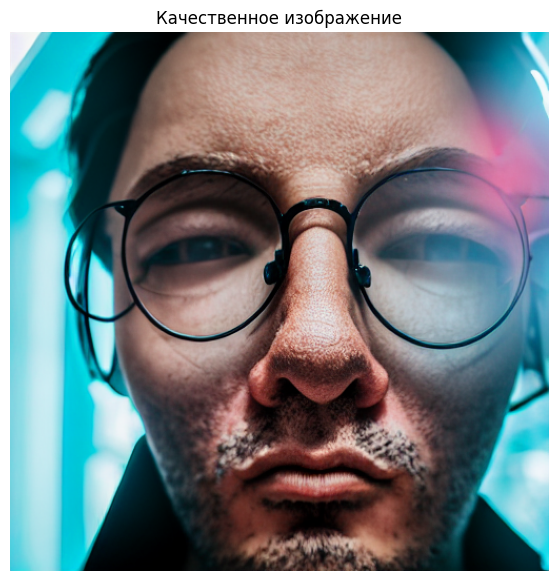

('photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, cyberpunk neon city at night, cinematic lighting, high quality, realism',
 PosixPath('output/00_showcase_cyberpunk.png'))

In [9]:
showcase = generated[0]
plt.figure(figsize=(7, 7))
plt.imshow(showcase["image"])
plt.title(showcase["title"])
plt.axis("off")
plt.show()

showcase["prompt"], showcase["path"]

## Еще 5 изображений

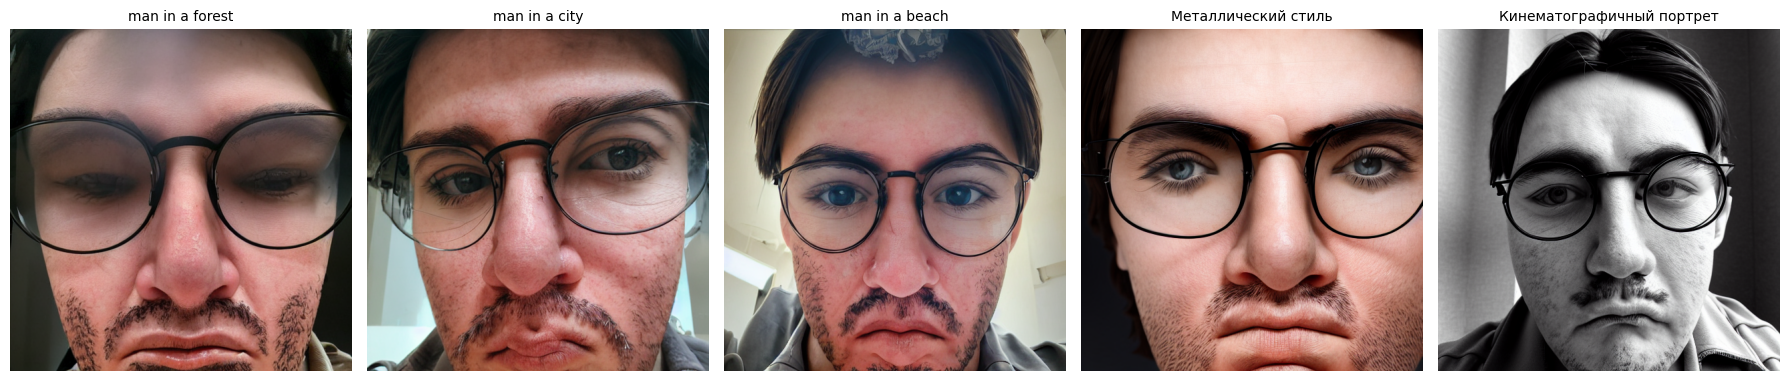

output/01_forest.png: photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, man in a forest, high quality, realism
output/02_city.png: photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, man in a city, high quality, realism
output/03_beach.png: photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, man in a beach, high quality, realism
output/04_metal.png: photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, polished metal skin, studio portrait, high quality, realism
output/05_vintage.png: photo of gera man, front-facing close-up portrait, face clearly visible, looking at camera, clear facial features, vintage film portrait, warm natural light, high quality, realism


In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, item in zip(axes, generated[1:]):
    ax.imshow(item["image"])
    ax.set_title(item["title"], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

for item in generated[1:]:
    print(f"{item['path']}: {item['prompt']}")